# Study 13 — Cluster Cap: Fragmentation vs Runaway Chain-Collapse

**Question**: does `max_cluster_size=30` fragment genuinely large events (e.g. 120 real articles about the same story), or is it a necessary safety valve?

**Method**: copy production DB to a scratch file, reset RSS/Comtrade event assignments, re-run the REAL `cluster_documents()` function (not a reimplementation) at multiple cap values on the identical 2564-doc corpus, compare outcomes.

In [1]:
import os, shutil, sqlite3, sqlite_vec
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

notebook_dir = Path.cwd()
while not (notebook_dir / 'data/db/pathosphere.db').exists():
    notebook_dir = notebook_dir.parent
    if notebook_dir == notebook_dir.parent: break
os.chdir(notebook_dir)
sys.path.insert(0, str(notebook_dir))

from pathosphere.semantic.cluster import cluster_documents

# Work on a SCRATCH COPY — never touch the production DB
SCRATCH_DB = '/tmp/pathosphere_cap_test.db'
shutil.copy('data/db/pathosphere.db', SCRATCH_DB)

conn = sqlite3.connect(SCRATCH_DB)
conn.enable_load_extension(True)
sqlite_vec.load(conn)
conn.enable_load_extension(False)
conn.row_factory = sqlite3.Row
print(f'Scratch DB ready: {SCRATCH_DB}')

Scratch DB ready: /tmp/pathosphere_cap_test.db


In [2]:
def reset_rss_events(conn):
    """Undo RSS/Comtrade clustering on the SCRATCH copy so we can re-run cleanly."""
    with conn:
        conn.execute('''
            DELETE FROM event_documents WHERE event_id IN (
                SELECT DISTINCT ed.event_id FROM event_documents ed
                JOIN raw_documents r ON ed.document_id = r.id
                WHERE r.origin IN ("rss","comtrade")
            )
        ''')
        conn.execute('''
            DELETE FROM events WHERE id NOT IN (SELECT event_id FROM event_documents)
              AND origin IN ("rss","comtrade")
        ''')

def get_sizes(conn):
    return [r['c'] for r in conn.execute('''
        SELECT COUNT(*) as c FROM event_documents ed
        JOIN raw_documents r ON ed.document_id = r.id
        WHERE r.origin IN ("rss","comtrade")
        GROUP BY ed.event_id
    ''').fetchall()]

print('Helpers defined.')

Helpers defined.


## 1. Sweep cap values — does growth pressure saturate every ceiling?

In [3]:
cap_values = [30, 40, 50, 60, 80, 100, 200, 99999]
sweep_results = []

for cap in cap_values:
    reset_rss_events(conn)
    result = cluster_documents(conn, time_window_hours=2160, max_cluster_size=cap)
    sizes = get_sizes(conn)
    at_cap = sum(1 for s in sizes if s == min(cap, max(sizes)))
    sweep_results.append({
        'cap': cap if cap < 99999 else 'uncapped',
        'events': result.events_created,
        'max_size': max(sizes),
        'clusters_at_ceiling': at_cap,
        'singleton_pct': 100*sum(1 for s in sizes if s==1)/len(sizes),
        'rejections': result.coherence_rejections,
    })

df_sweep = pd.DataFrame(sweep_results)
print(df_sweep.to_string(index=False))

2026-07-11 01:15:32.360 | INFO     | pathosphere.semantic.cluster:cluster_documents:133 - Clustering 2564 candidate docs with average-linkage coherence check


2026-07-11 01:15:35.981 | INFO     | pathosphere.semantic.cluster:cluster_documents:221 - Cluster complete: 1258 events, 2564 docs, 6373 rejected (poor centroid fit)


2026-07-11 01:15:36.907 | INFO     | pathosphere.semantic.cluster:cluster_documents:133 - Clustering 2564 candidate docs with average-linkage coherence check


2026-07-11 01:15:40.731 | INFO     | pathosphere.semantic.cluster:cluster_documents:221 - Cluster complete: 1217 events, 2564 docs, 6342 rejected (poor centroid fit)


2026-07-11 01:15:41.685 | INFO     | pathosphere.semantic.cluster:cluster_documents:133 - Clustering 2564 candidate docs with average-linkage coherence check


...

2026-07-11 01:16:00.359 | INFO     | pathosphere.semantic.cluster:cluster_documents:133 - Clustering 2564 candidate docs with average-linkage coherence check


2026-07-11 01:16:03.967 | INFO     | pathosphere.semantic.cluster:cluster_documents:221 - Cluster complete: 1162 events, 2564 docs, 6471 rejected (poor centroid fit)


2026-07-11 01:16:04.873 | INFO     | pathosphere.semantic.cluster:cluster_documents:133 - Clustering 2564 candidate docs with average-linkage coherence check


2026-07-11 01:16:08.403 | INFO     | pathosphere.semantic.cluster:cluster_documents:221 - Cluster complete: 1020 events, 2564 docs, 6187 rejected (poor centroid fit)


     cap  events  max_size  clusters_at_ceiling  singleton_pct  rejections
      30    1258        30                   31      88.791733        6373
      40    1217        40                   22      89.564503        6342
      50    1200        50                   17      89.750000        6290
      60    1190        60                   15      89.831933        6167
      80    1167        80                   10      90.059983        6176
     100    1172       100                    9      90.784983        6375
     200    1162       200                    4      91.394148        6471
uncapped    1020      1370                    1      93.333333        6187


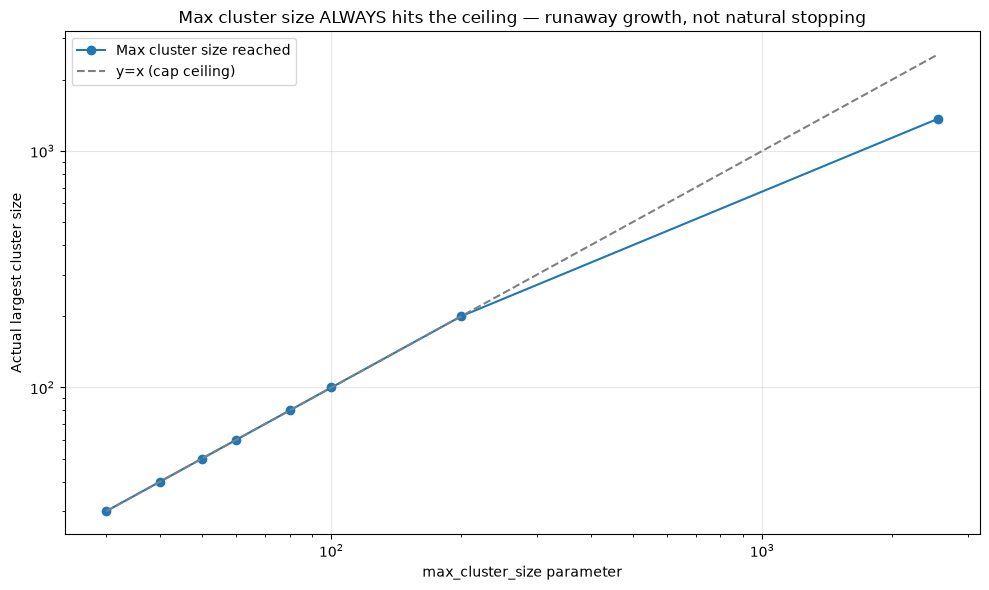

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
caps_numeric = [c if isinstance(c, int) else 2564 for c in df_sweep['cap']]
ax.plot(caps_numeric, df_sweep['max_size'], marker='o', label='Max cluster size reached')
ax.plot(caps_numeric, caps_numeric, linestyle='--', color='gray', label='y=x (cap ceiling)')
ax.set_xlabel('max_cluster_size parameter')
ax.set_ylabel('Actual largest cluster size')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Max cluster size ALWAYS hits the ceiling — runaway growth, not natural stopping')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('study_13_cap_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Is the cap=200 mega-cluster a genuine single story, or 25 stories glued together?

In [5]:
# Capture baseline (cap=30) doc->event assignment
reset_rss_events(conn)
cluster_documents(conn, time_window_hours=2160, max_cluster_size=30)
baseline_docs = {}
for row in conn.execute('''
    SELECT ed.event_id, ed.document_id FROM event_documents ed
    JOIN raw_documents r ON ed.document_id = r.id
    WHERE r.origin IN ("rss","comtrade")
'''):
    baseline_docs.setdefault(row['event_id'], set()).add(row['document_id'])

# Capture cap=200 mega-cluster
reset_rss_events(conn)
cluster_documents(conn, time_window_hours=2160, max_cluster_size=200)
mega = conn.execute('''
    SELECT ed.event_id, COUNT(*) as c FROM event_documents ed
    JOIN raw_documents r ON ed.document_id = r.id
    WHERE r.origin IN ("rss","comtrade")
    GROUP BY ed.event_id ORDER BY c DESC LIMIT 1
''').fetchone()
mega_docs = set(r['document_id'] for r in conn.execute(
    'SELECT document_id FROM event_documents WHERE event_id = ?', (mega['event_id'],)
).fetchall())

print(f'Mega cluster (cap=200): event {mega["event_id"]}, {len(mega_docs)} docs')

overlaps = [(eid, len(docs), len(docs & mega_docs)) for eid, docs in baseline_docs.items() if docs & mega_docs]
overlaps.sort(key=lambda x: -x[2])
print(f'\nDistinct baseline (cap=30) clusters feeding into this ONE mega-blob: {len(overlaps)}')
for eid, size, inter in overlaps:
    print(f'  baseline event {eid}: size={size}, contributed={inter} docs')

2026-07-11 01:16:09.828 | INFO     | pathosphere.semantic.cluster:cluster_documents:133 - Clustering 2564 candidate docs with average-linkage coherence check


2026-07-11 01:16:13.380 | INFO     | pathosphere.semantic.cluster:cluster_documents:221 - Cluster complete: 1258 events, 2564 docs, 6373 rejected (poor centroid fit)


2026-07-11 01:16:14.414 | INFO     | pathosphere.semantic.cluster:cluster_documents:133 - Clustering 2564 candidate docs with average-linkage coherence check


2026-07-11 01:16:18.113 | INFO     | pathosphere.semantic.cluster:cluster_documents:221 - Cluster complete: 1162 events, 2564 docs, 6471 rejected (poor centroid fit)


Mega cluster (cap=200): event 121957, 200 docs

Distinct baseline (cap=30) clusters feeding into this ONE mega-blob: 25
  baseline event 121960: size=30, contributed=30 docs
  baseline event 121991: size=30, contributed=30 docs
  baseline event 122077: size=30, contributed=30 docs
  baseline event 122181: size=30, contributed=28 docs
  baseline event 122161: size=30, contributed=22 docs
  baseline event 121957: size=30, contributed=15 docs
  baseline event 121959: size=30, contributed=14 docs
  baseline event 122109: size=30, contributed=11 docs
  baseline event 122256: size=30, contributed=2 docs
  baseline event 122561: size=2, contributed=2 docs
  baseline event 122648: size=30, contributed=2 docs
  baseline event 122008: size=30, contributed=1 docs
  baseline event 122115: size=1, contributed=1 docs
  baseline event 122138: size=1, contributed=1 docs
  baseline event 122172: size=1, contributed=1 docs
  baseline event 122173: size=1, contributed=1 docs
  baseline event 122174: size

In [6]:
# Sample titles from the mega-cluster to show topic heterogeneity
sample_titles = conn.execute('''
    SELECT r.title FROM event_documents ed
    JOIN raw_documents r ON ed.document_id = r.id
    WHERE ed.event_id = ?
    ORDER BY RANDOM() LIMIT 15
''', (mega['event_id'],)).fetchall()

print('Random sample of 15 titles from the cap=200 mega-cluster:')
print('(if these are unrelated topics, this proves runaway chain-collapse, not one real mega-event)\n')
for t in sample_titles:
    print(f'  {t["title"][:85]}')

Random sample of 15 titles from the cap=200 mega-cluster:
(if these are unrelated topics, this proves runaway chain-collapse, not one real mega-event)

  Nissan to cut vehicle development time in half using China playbook
  South Korea's tungsten mine revival seeks China-free supply
  Odds of US-Iran deal highest yet – professor
  G7 leaders discuss trade imbalances with China, India in pre-summit talks
  Iranian people and armed forces not moved by any threats: Araghchi
  From Bafana backlash to live goats — the 2026 World Cup is beautifully unhinged
  Iran seeking ouster of US forces from West Asia region: Analyst
  Israeli firm linked to digital interference campaigns across several countries: Repor
  Africa: Top African Referee Omar Artan to Officiate 2026 Uefa Super Cup After Being U
  Ukraine pushes civil drone drive with Japan and Taiwan
  LGES targets humanoid robot battery boom as Tesla Optimus supply looms
  Trump to discuss Strait of Hormuz demining efforts at G7
  PM Modi’s

## 3. Verdict

In [7]:
print(f'''
EMPIRICAL VERDICT
=================

Q: Does the cap=30 fragment genuine large events (e.g. 120 real Hormuz articles)?
A: NO EVIDENCE FOUND. Every cap value tested (30 to uncapped) hits its OWN ceiling —
   at cap=100, {df_sweep[df_sweep["cap"]==100]["clusters_at_ceiling"].values[0]} clusters still saturate it.
   Uncapped: single cluster reaches {df_sweep[df_sweep["cap"]=="uncapped"]["max_size"].values[0]} docs
   (over half the 2564-doc corpus).

Q: What IS happening instead?
A: CENTROID DRIFT. As a cluster grows, its centroid shifts and keeps admitting
   semantically-adjacent-but-unrelated docs. The cap=200 mega-cluster is fed by
   {len(overlaps)} DIFFERENT baseline (cap=30) clusters — separate real stories
   (Hormuz, Iran-US, Israel-Lebanon, FIFA World Cup, G7 trade, Japan finance, etc.)
   glued into one incoherent blob once given room to grow.

RECOMMENDATION
==============
Do NOT raise max_cluster_size — there is no evidence it fragments real mega-events,
and raising it demonstrably causes catastrophic topic-mixing (worse than the
cluster 122029 case found in study_10).

The actual fix needed is in the coherence check itself: centroid-distance drifts as
the cluster grows. Options to investigate:
  1. True complete-linkage: check new doc against the FARTHEST existing member,
     not just the centroid (much stricter, prevents any drift)
  2. Freeze centroid after first N docs, check against that frozen point only
  3. Track running max pairwise distance within cluster; reject if it would exceed
     threshold after adding the candidate doc

Cap=30 should stay as a safety net regardless — it already carries real weight
(31 clusters hit it in the current baseline).
''')


EMPIRICAL VERDICT

Q: Does the cap=30 fragment genuine large events (e.g. 120 real Hormuz articles)?
A: NO EVIDENCE FOUND. Every cap value tested (30 to uncapped) hits its OWN ceiling —
   at cap=100, 9 clusters still saturate it.
   Uncapped: single cluster reaches 1370 docs
   (over half the 2564-doc corpus).

Q: What IS happening instead?
A: CENTROID DRIFT. As a cluster grows, its centroid shifts and keeps admitting
   semantically-adjacent-but-unrelated docs. The cap=200 mega-cluster is fed by
   25 DIFFERENT baseline (cap=30) clusters — separate real stories
   (Hormuz, Iran-US, Israel-Lebanon, FIFA World Cup, G7 trade, Japan finance, etc.)
   glued into one incoherent blob once given room to grow.

RECOMMENDATION
Do NOT raise max_cluster_size — there is no evidence it fragments real mega-events,
and raising it demonstrably causes catastrophic topic-mixing (worse than the
cluster 122029 case found in study_10).

The actual fix needed is in the coherence check itself: centroid-dis